# Firm characteristics: strong features, and a target that decides the fit

The features in this case study are not invented for the book. They are the cross-section of
firm characteristics the asset pricing literature has spent thirty years assembling: value in
several forms (`BEME`, `E2P`, `S2P`, `CF2P`), profitability (`ROA`, `ROE`, `OP`, `PROF`),
investment and accruals (`Investment`, `NOA`, `OA`), size (`LME`), momentum at several formation
windows (`r2_1`, `r12_2`, `r12_7`, `r36_13`), reversal, and a set of risk and liquidity measures
(`IdioVol`, `Resid_Var`, `Variance`, `Spread`, `Beta`). Each arrives with published evidence that
it orders the cross-section of monthly stock returns.

That makes this the one case study where the features are not in question, and it lets the
notebook ask a cleaner question than "do these predict". `04_evaluation` has already screened
them one at a time and found what the literature would lead you to expect. **The question here is
what happens when you fit a linear model to all of them at once, and it turns out to be a
question about the target rather than about the features.**

A monthly cross-section of individual US stocks is not a well-behaved regression target. Most
firms move a few percent; a small number of them multiply. `02_labels` measures the resulting
kurtosis directly and is where the case study's winsorized variant comes from. The consequence
for this notebook is specific and worth stating before any results appear: a linear model fits by
**minimizing squared error**, so a firm that returned many multiples of its price contributes to
the objective in proportion to the square of that return, while the **information coefficient**
this notebook reports is a rank correlation that treats it as one observation among thousands.
Those are different targets, and section 6 reads the results in that light.

The design matrix also has the redundancy every case study here has - four momentum windows,
three variance measures, six composites and four explicit interaction terms built from columns
already present - so the penalty sweep has its usual job. **Regularization** adds a penalty on
coefficient size to the fitting objective, and how much to apply is an empirical question this
notebook answers by trying ten orders of magnitude of it.

**Learning objectives.** By the end of this notebook you will be able to:

- Read the set of models a case study has declared for a label, and say which estimator and
  which hyperparameters each declared name resolves to.
- Bind those declarations to the data on disk and check, before anything is fitted, that every
  configuration will be measured on the same firms, the same months and the same folds.
- Fit a population of models on walk-forward folds and publish one complete set of validation
  predictions per configuration.
- Say why a squared-error fit and a rank correlation can disagree about the same model, and
  recognise the distributional shape that makes them disagree.
- Tell apart a result that is about the features from one that is about the target.
- Run configurations of your own into a private copy of the run log, and have them compared on
  the same footing as the ones shipped here.

**Book reference**: Chapter 11 (The ML Pipeline). Chapter 6, Section 6.7 (Search accounting and
run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`02_labels`](02_labels.ipynb) has constructed the monthly returns and the
winsorized variant, [`03_financial_features`](03_financial_features.ipynb) has written the
characteristics, and [`04_evaluation`](04_evaluation.ipynb) has established the walk-forward
folds and screened the characteristics individually.

**What it writes**: one training run and one complete validation prediction set per
configuration, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`11_backtest`](11_backtest.ipynb) reads that population, runs every member against the
equal-weight baseline, and selects on validation backtest Sharpe. **Selection happens there,
not here.** This notebook ranks configurations by information coefficient to show what
regularization does to this feature set; that ranking decides nothing.

In [1]:
"""Fit the declared firm-characteristics linear-model population on the walk-forward folds."""

import re

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABEL = "fwd_ret_1m"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = "us_firm_characteristics-linear-validation-v1"

In [3]:
study = open_study(
    "us_firm_characteristics", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which label, and which models

A label is the thing being predicted. This case study defines three in `config/setup.yaml`.
`fwd_ret_1m`, the firm's total return over the month after the decision date, is the primary
one - the horizon the strategy chapters trade. `fwd_ret_1m_win` is the same return with each
month's cross-section clipped at its own tails, and `fwd_class_1m` is a classification variant
that asks which bucket the return falls in rather than how large it is. `02_labels` builds all
three and shows how far apart the raw and clipped distributions are in the tails.

**This notebook fits one label per run.** `LABEL` above selects it, and every choice below
follows from that one setting, because each label has its own training menu at
`config/training/{label}.yaml`. The menu lists, family by family, the named configurations to
fit for that label. Changing `LABEL` to a variant and re-running fits that variant's declared
grid into its own population, which is how the three are compared without any of them being
privileged in code.

In [4]:
declared_labels(study, "linear")

('fwd_class_1m', 'fwd_ret_1m', 'fwd_ret_1m_win')

Each name in the menu resolves to a preset file in the shared directory
`case_studies/config/{model_type}/`, which holds that configuration's hyperparameters. The
frame below is the menu for `LABEL`, with each name resolved to the estimator class it names
and the arguments that class is constructed with. To change what runs, edit the menu or the
presets rather than this notebook.

The grid covers the two shapes a penalty can take:

- **Ridge** penalizes the sum of squared coefficients. It shrinks correlated coefficients
  towards each other and keeps every feature, at a strength set by `alpha`. The grid steps
  `alpha` by powers of ten across ten orders of magnitude, because the useful value depends on
  the scale and the collinearity of the design matrix and neither is known in advance.
- **Lasso** penalizes the sum of absolute coefficients, which drives some of them exactly to
  zero: it selects features rather than shrinking them. **ElasticNet** mixes the two.

Lasso and ElasticNet are parameterized here by `alpha_frac` rather than a raw penalty. For any
fold there is a threshold penalty $\alpha_{\max}$ - the smallest one that zeros every
coefficient - which is computed from that fold's own data. `alpha_frac` is the fraction of it
to apply, so one declared `alpha_frac` means the same thing on every fold, while a fixed raw
penalty would mean something different on each.

In [5]:
configs = load_model_configs(
    study,
    "linear",
    labels=[LABEL],
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""linear""","""fwd_ret_1m""","""ols""","""LinearRegression""","""defaults"""
"""linear""","""fwd_ret_1m""","""ridge_a0.001""","""Ridge""","""alpha=0.001"""
"""linear""","""fwd_ret_1m""","""ridge_a0.01""","""Ridge""","""alpha=0.01"""
"""linear""","""fwd_ret_1m""","""ridge_a0.1""","""Ridge""","""alpha=0.1"""
"""linear""","""fwd_ret_1m""","""ridge_a1.0""","""Ridge""","""alpha=1.0"""
…,…,…,…,…
"""linear""","""fwd_ret_1m""","""enet_f0.03""","""ElasticNet""","""alpha_frac=0.03, l1_ratio=0.5,…"
"""linear""","""fwd_ret_1m""","""enet_f0.015""","""ElasticNet""","""alpha_frac=0.015, l1_ratio=0.5…"
"""linear""","""fwd_ret_1m""","""enet_f0.35""","""ElasticNet""","""alpha_frac=0.35, l1_ratio=0.5,…"


## 2. Binding the declarations to the data

A menu entry says which estimator to fit. It does not say which feature columns exist today,
where the walk-forward folds fall, or which firm-month pairs have both a feature row and a
label. **Resolving** a request is the step that goes and finds all of that: it reads the label
and feature files, computes the fold boundaries from the walk-forward parameters in
`config/setup.yaml`, works out the exact set of rows each fit is expected to predict, and turns
any data-dependent hyperparameter into the number it will actually use - each fold's own
$\alpha_{\max}$ times `alpha_frac`, in the case of Lasso.

Resolving reads the inputs and fits nothing, so the plan below can be inspected before any
computation starts. The three things to check in it:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** They are
  the width of the design matrix, the number of firms that appear anywhere in the sample, and
  the number of firm-month pairs to be predicted. Every configuration here reads the same
  feature matrix, so a row that differs is a configuration being measured on a different sample
  from its neighbours, and its results are not comparable with theirs. `eligible_entities`
  counts firms over the whole period rather than in any one month: the universe turns over as
  firms list and delist, and a typical month holds a fraction of that total.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  `04_evaluation` established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: it is scored once, at the end of the case study, and any of it visible
  in this window would mean it had been used to choose something.

Each row also carries a `training_hash`: the identity of that computation, derived from
everything that can change its result. [`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes
into one and what follows from it.

In [6]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,validation_start,validation_end
str,i64,i64,i64,i64,date,date
"""enet_f0.015""",57,3708,252008,10,2006-11-30,2015-12-31
"""enet_f0.03""",57,3708,252008,10,2006-11-30,2015-12-31
"""enet_f0.08""",57,3708,252008,10,2006-11-30,2015-12-31
"""enet_f0.2""",57,3708,252008,10,2006-11-30,2015-12-31
"""enet_f0.35""",57,3708,252008,10,2006-11-30,2015-12-31
…,…,…,…,…,…,…
"""ridge_a1000.0""",57,3708,252008,10,2006-11-30,2015-12-31
"""ridge_a10000.0""",57,3708,252008,10,2006-11-30,2015-12-31
"""ridge_a100000.0""",57,3708,252008,10,2006-11-30,2015-12-31


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. fills missing feature values with the training window's median for that column, then
   standardizes each column to zero mean and unit variance - both fitted on training rows only
   and then applied to the validation rows, so nothing from the validation window reaches the
   fit,
3. fits the estimator with that fold's resolved parameters,
4. predicts the fold's validation rows.

The fold predictions are concatenated into one series covering the whole validation period,
which is what a walk-forward prediction set is: each month predicted by a model that saw only
data before it. The run then writes a `training_runs` row and the fitted coefficients, a
`prediction_sets` row and the predictions themselves, and the metrics computed from them. It
does this per configuration rather than once at the end, so an interruption costs the
configuration in flight and nothing else.

Every case study that fits linear models calls this same runner, which is what makes their
results comparable. Unlike gradient boosting or a neural network, a linear model has no
intermediate states worth scoring: there is one fit and therefore one checkpoint per
configuration, and no learning curve to plot.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
is going to produce. The list is computed from the resolved specifications before the first fit
and written down, and afterwards every member must exist and be complete. That is what makes
the downstream comparison well defined - `11_backtest` backtests this population, not whatever
predictions happen to be in the registry - and it is why a configuration that raises fails the
whole call rather than publishing a population one member short. Everything that finished stays
registered, and re-running fits only what is missing.

In [7]:
execution, population = run_model_population(study, resolved, population_name=POPULATION_NAME)

fitted = sum(len(item["fitted_folds"]) for item in execution.diagnostics)
reused = sum(len(item["reused_folds"]) for item in execution.diagnostics)
print(f"{len(execution.runs)} configurations: {fitted} folds fitted, {reused} reused")
print(f"population {population.name}: {len(population.members)} prediction sets")

28 configurations: 0 folds fitted, 280 reused
population us_firm_characteristics-linear-validation-v1: 28 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the
registry already holds the matching rows, and the runner returns the stored result rather than
fitting again - so re-running this notebook unchanged costs the time it takes to read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which
holds its own registry and artifacts and reads the same labels and features:

```python
study = open_study("us_firm_characteristics", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "linear", labels=["fwd_ret_1m"], config_names=["ols", "ridge_a1.0", "ridge_a3.0"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-linear-v1")
```

`CONFIG_NAMES` fits a subset of what the menu already declares; a name the menu does not
declare raises rather than quietly fitting fewer models than you asked for. To fit something
new, add a preset at `case_studies/config/ridge/ridge_a3.0.yaml` and list `ridge_a3.0` under
`linear:` in the label's menu. Editing an existing preset changes that configuration's
identity, so its result registers as a new row beside the old one instead of replacing it.

Give the run its own `population_name`: a name refers to one set of members permanently, and
reusing it for a different set raises. Everything downstream reads the registry rather than the
notebook, so predictions produced this way are selected and backtested on the same footing as
the ones shipped here, inside your workspace.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest, including how to
rehearse on a reduced universe first.

## 4. What the target looks like

Before the model results, the target itself, because its shape is what the results below turn
on. Each observation is one firm's total return over one month. The count axis is logarithmic,
because a linear one wide enough to show the right tail would compress everything else into a
single bar.

The distribution is not symmetric and it is not thin-tailed. A firm can lose at most everything,
so there is a floor at a return of minus one; there is no corresponding ceiling, and the largest
observations in this sample are multiples of the starting price. `02_labels` quantifies the
kurtosis and builds the winsorized variant in response to it. What matters here is the
arithmetic of a squared-error fit: an observation ten times further from the prediction than
another contributes a hundred times as much to what the fit is minimizing.

In [8]:
label_values = (
    study.labels.get(LABEL, execution_tier=EXECUTION_TIER)
    .load()
    .get_column(LABEL)
    .drop_nulls()
    .to_numpy()
)

summary = pl.DataFrame(
    {
        "statistic": [
            "minimum",
            "median",
            "mean",
            "maximum",
            "standard deviation",
            "share above 1",
        ],
        "value": [
            float(label_values.min()),
            float(np.median(label_values)),
            float(label_values.mean()),
            float(label_values.max()),
            float(label_values.std()),
            float((label_values > 1).mean()),
        ],
    }
)
summary

statistic,value
str,f64
"""minimum""",-0.960633
"""median""",0.0
"""mean""",0.011183
"""maximum""",18.9975
"""standard deviation""",0.17403
"""share above 1""",0.002142


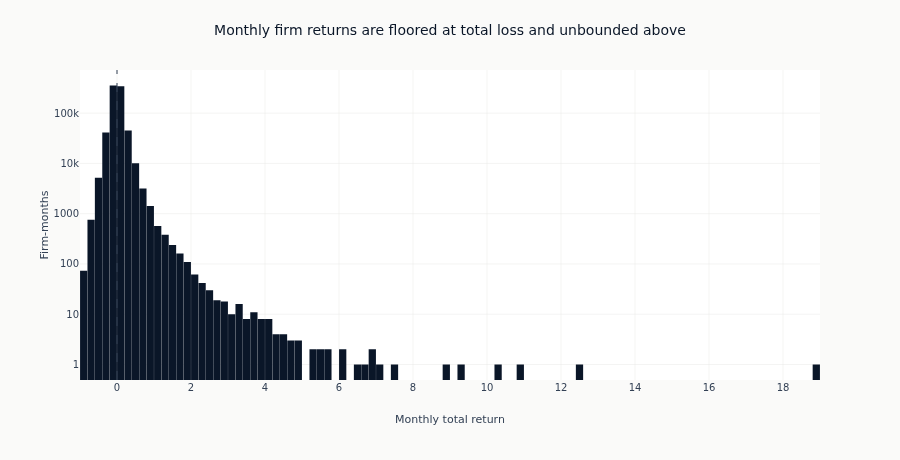

In [9]:
fig_label = go.Figure(go.Histogram(x=label_values, nbinsx=140, marker_color=COLORS["blue"]))
fig_label.add_vline(x=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_label.update_layout(
    title="Monthly firm returns are floored at total loss and unbounded above",
    height=460,
    width=900,
    showlegend=False,
    margin=dict(t=70),
    bargap=0.02,
)
fig_label.update_xaxes(title_text="Monthly total return")
fig_label.update_yaxes(title_text="Firm-months", type="log")
show_plotly_with_alt(
    fig_label,
    "Histogram of monthly firm total returns on a logarithmic count axis. Almost all the mass "
    "sits in a narrow band around a dashed line at zero, with a hard edge at minus one and a long "
    "thin tail of large positive returns extending far to the right.",
)

## 5. What the models produced

One row per configuration, read back from the registry. `ic_mean` is the **information
coefficient**: in each validation month, rank the firms by the model's prediction, rank them by
the return they went on to earn, correlate the two rankings, and average that monthly
correlation over the validation period. It measures whether the model ranks firms correctly, on
a scale where zero is no relationship, positive means the ranking points the right way, and
negative means it points the wrong way.

`ic_n_days` is how many validation months produced a defined correlation. A model whose
coefficients collapse to one or two features predicts nearly the same value for every firm in
some months, and a constant has no rank correlation with anything, so those months would
contribute nothing. `full_coverage` marks the configurations measured on all of them.

In [10]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "complete",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort("ic_mean", descending=True)
    .join(configs.select("config_name", "model_class", "params"), on="config_name", how="left")
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("linear execution returned a partial prediction set")

full_days = int(catalog.get_column("ic_n_days").max())
catalog = catalog.with_columns(full_coverage=pl.col("ic_n_days") == full_days)
catalog.select(
    "config_name",
    "model_class",
    "params",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
)

config_name,model_class,params,ic_mean,ic_std,ic_n_days,full_coverage
str,str,str,f64,f64,f64,bool
"""lasso_f0.85""","""Lasso""","""alpha_frac=0.85, max_iter=5000""",-0.003594,0.030888,110.0,true
"""enet_f0.85""","""ElasticNet""","""alpha_frac=0.85, l1_ratio=0.5,…",-0.003595,0.030888,110.0,true
"""ridge_a0.01""","""Ridge""","""alpha=0.01""",-0.0048,0.025954,110.0,true
"""ridge_a0.001""","""Ridge""","""alpha=0.001""",-0.0048,0.025954,110.0,true
"""ols""","""LinearRegression""","""defaults""",-0.0048,0.025954,110.0,true
…,…,…,…,…,…,…
"""lasso_f0.35""","""Lasso""","""alpha_frac=0.35, max_iter=5000""",-0.010209,0.027452,110.0,true
"""enet_f0.35""","""ElasticNet""","""alpha_frac=0.35, l1_ratio=0.5,…",-0.01023,0.02746,110.0,true
"""ridge_a100000.0""","""Ridge""","""alpha=100000.0""",-0.010357,0.026786,110.0,true


### How the penalty grid ranks

Only the configurations measured on all `full_days` validation months are charted. The zero line
is the reference that matters: a bar below it is a model whose ranking pointed the wrong way out
of sample.

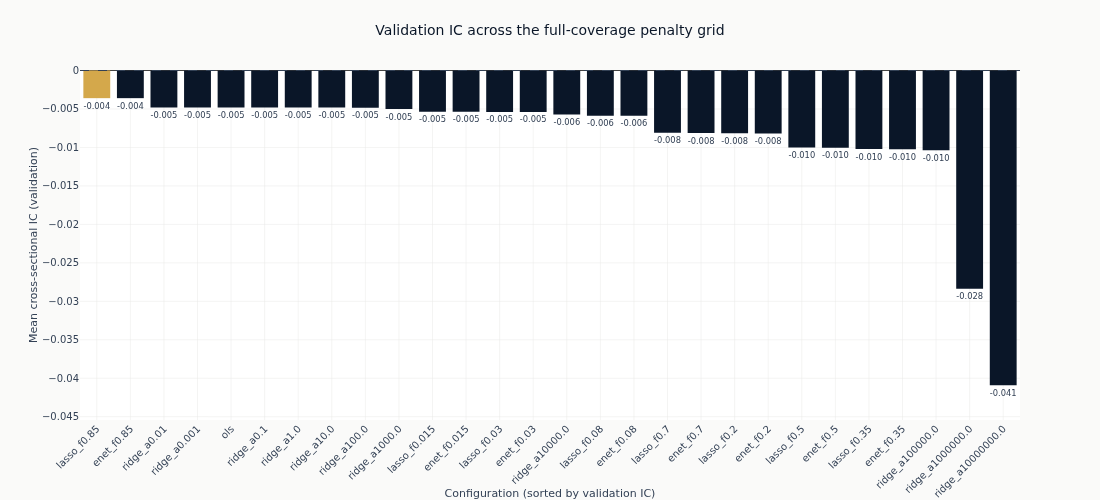

In [11]:
def compact(params: str) -> str:
    """Render declared parameters for a label: `alpha=1000000.0` reads as `alpha=1e+06`."""
    return re.sub(r"\d+\.?\d*(?:[eE][+-]?\d+)?", lambda m: f"{float(m.group()):g}", params)


full = catalog.filter("full_coverage")
leader = full.row(0, named=True)

fig_ic = go.Figure(
    go.Bar(
        x=full.get_column("config_name").to_list(),
        y=full.get_column("ic_mean").to_list(),
        marker_color=[
            COLORS["amber"] if name == leader["config_name"] else COLORS["blue"]
            for name in full.get_column("config_name")
        ],
        text=[f"{value:+.3f}" for value in full.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_ic.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_ic.update_layout(
    title="Validation IC across the full-coverage penalty grid",
    height=500,
    width=1100,
    showlegend=False,
    margin=dict(t=70),
)
fig_ic.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_ic.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_ic,
    "Bar chart of mean validation information coefficient for every full-coverage linear "
    f"configuration, sorted descending, against a dashed zero line. {leader['config_name']} "
    f"({compact(leader['params'])}) is highlighted in amber at the top of the ranking at IC "
    f"{leader['ic_mean']:+.3f}. Every bar falls below the zero line.",
)

### What shrinkage does on its own

The bar chart mixes three estimators. Tracing IC across the Ridge penalty alone isolates the
effect of shrinkage, with the estimator, the features and the folds all held fixed and only
`alpha` moving. The alpha is read from each configuration's declared parameters rather than
parsed out of its name, so the curve plots what was fitted.

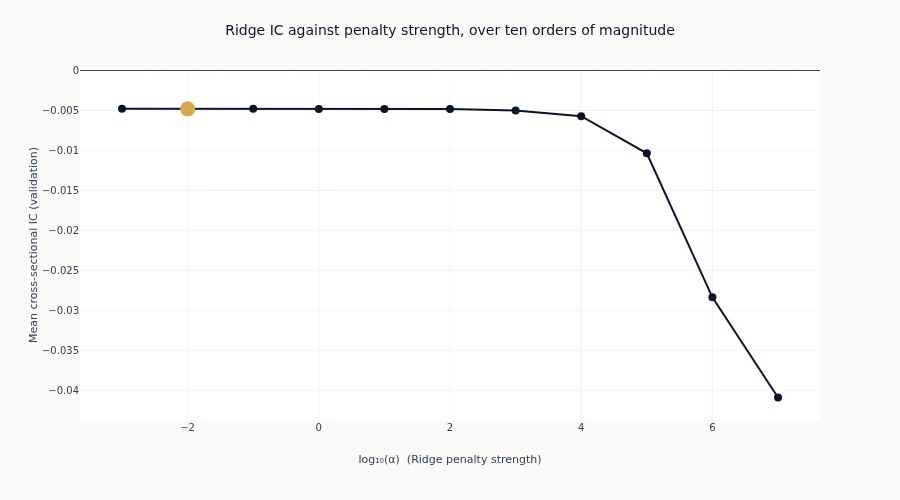

In [12]:
ridge = (
    catalog.filter(pl.col("model_class") == "Ridge")
    .with_columns(
        alpha=pl.col("params").str.extract(r"alpha=([0-9.eE+-]+)").cast(pl.Float64),
    )
    .drop_nulls("alpha")
    .sort("alpha")
)
if ridge.height:
    log_alpha = np.log10(ridge.get_column("alpha").to_numpy())
    ridge_ic = ridge.get_column("ic_mean").to_numpy()
    peak = int(np.argmax(ridge_ic))

    fig_alpha = go.Figure(
        go.Scatter(
            x=log_alpha,
            y=ridge_ic,
            mode="lines+markers",
            line=dict(color=COLORS["blue"], width=2),
            marker=dict(size=8, color=COLORS["blue"]),
        )
    )
    fig_alpha.add_trace(
        go.Scatter(
            x=[log_alpha[peak]],
            y=[ridge_ic[peak]],
            mode="markers",
            marker=dict(size=15, color=COLORS["amber"]),
            showlegend=False,
        )
    )
    fig_alpha.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
    fig_alpha.update_layout(
        title="Ridge IC against penalty strength, over ten orders of magnitude",
        height=500,
        width=900,
        showlegend=False,
        margin=dict(t=70),
    )
    fig_alpha.update_xaxes(title_text="log₁₀(α)  (Ridge penalty strength)", zeroline=False)
    fig_alpha.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    show_plotly_with_alt(
        fig_alpha,
        "Line chart of mean validation information coefficient against the base-ten logarithm of the "
        "Ridge penalty, against a dashed zero line. The curve sits just below zero and flat across "
        f"most of the range, with its maximum at 1e{int(round(log_alpha[peak]))} marked in amber, "
        "then drops steeply at the two strongest penalties.",
    )
else:
    print(
        f"{LABEL} declares no Ridge configurations, so there is no penalty sweep to trace. "
        f"Which estimators this section can show is decided by the menu at "
        f"config/training/{LABEL}.yaml."
    )

## 6. What to notice

**No configuration clears zero, and that is a result about the target.** Read it against
`04_evaluation`, which screened these same characteristics one at a time on these same folds and
found the cross-sectional orderings the literature describes. The signal is in the columns. What
this notebook adds is that fitting a linear model to all of them at once, against this target,
does not recover it - and a result that contradicts a feature screen run on the same data is a
statement about what happens in between, not about the features.

**The two things being compared are not the same thing.** The fit minimizes squared error in
return space, where a firm that tripled sits hundreds of times further from any prediction than
a typical firm and therefore dominates what the coefficients are chosen to do. The metric is a
rank correlation in each month's cross-section, where that same firm is one name near the top of
a list of a couple of thousand. A procedure tuned almost entirely by the extreme right tail is
being graded on an ordering that barely notices it. Nothing about that is a defect in either
choice; they are answers to different questions, and the grid is the evidence of how far apart
the answers can be.

**This is what the winsorized variant is for.** `02_labels` builds `fwd_ret_1m_win` by clipping
each month's cross-section at its own tails, precisely because a monthly cross-section of
individual stocks is not something a squared-error procedure handles well. Setting `LABEL` above
to that variant and re-running fits the same grid, on the same folds, against the same
characteristics, and publishes it as its own population - which is the controlled comparison,
one variable changed, and the way to see the size of the effect described here rather than take
it on trust.

**The strongest shrinkage hurts rather than helps.** The Ridge curve is flat across most of
its range and falls at the two largest penalties. That is the opposite of the collinearity story
in the other case studies, where shrinkage helps. Here the fit is not being defeated by
correlated columns, so removing coefficient magnitude removes what little the fit has without
fixing the reason it is misaligned.

**None of this selects anything.** IC measures whether predictions rank firms correctly, not
whether a strategy trading them makes money after costs and turnover. A monthly rebalance across
thousands of names is where turnover costs bite hardest, and the smallest firms - the ones with
the widest `Spread` in this feature set - are where a paper ranking is most likely to be
untradable. Selection is on validation backtest Sharpe over the population this notebook just
published, and it happens in [`11_backtest`](11_backtest.ipynb).

**Known limitations.** The IC is an average of monthly rank correlations with no adjustment for
the dependence across months that persistent characteristics induce, so it is a ranking
diagnostic rather than a test; `04_evaluation` does that inference for individual
characteristics. The grid is a one-dimensional sweep of penalty strength at fixed features and
fixed folds. And every number here is measured on the validation folds, which have been read
many times over by the time a case study reaches this notebook.

**Next**: [`06_gbm`](06_gbm.ipynb) fits gradient boosting to the same target. It minimizes the
same squared error by default, so the comparison to watch is whether its extra flexibility goes
into the ranking or into describing the same right tail more finely - and
[`10_model_analysis`](10_model_analysis.ipynb) is where that question is settled rather than
guessed at.